In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using: {device}")

Using: cuda


In [2]:
!kaggle datasets download -d rickyyyyyyy/torchvision-stanford-cars
!mkdir -p extra_data
!unzip -q torchvision-stanford-cars.zip -d extra_data/car_data

Dataset URL: https://www.kaggle.com/datasets/rickyyyyyyy/torchvision-stanford-cars
License(s): other
100% 1.83G/1.83G [00:20<00:00, 94.0MB/s]



In [4]:
df=pd.read_csv("stanford_cars_full_dataset.csv")
df.head()

,class_id,class_name,manufacturer,model,year,origin_country,body_type,horsepower,engine,0_to_60_mph_sec,top_speed_mph,transmission,avg_price_usd
0,1,AM General Hummer SUV 2000,AM General,Hummer,2000,USA,SUV,323,2.5L 4-Cylinder,6.1,132,Automatic,26296
1,2,Acura RL Sedan 2012,Acura,RL,2012,Japan,Sedan,529,1.8L 8-Cylinder,6.0,142,Automatic,56395
2,3,Acura TL Sedan 2012,Acura,TL,2012,Japan,Sedan,508,2.5L 12-Cylinder,5.9,185,Manual,48478
3,4,Acura TL Type-S 2008,Acura,TL Type-S,2008,Japan,Other,392,3.0L 4-Cylinder,6.4,150,Manual,45851
4,5,Acura TSX Sedan 2012,Acura,TSX,2012,Japan,Sedan,360,3.1L 6-Cylinder,4.8,164,Automatic,89118


In [5]:
df.isnull().sum()

,0
class_id,0
class_name,0
manufacturer,0
model,0
year,0
origin_country,0
body_type,0
horsepower,0
engine,0
0_to_60_mph_sec,0


In [6]:
print(f"  Total cars       : {len(df)}")
print(f"  Countries        : {df['origin_country'].nunique()}")
print(f"  Body types       : {df['body_type'].nunique()}")
print(f"  Year range       : {df['year'].min()} – {df['year'].max()}")
print(f"  Avg horsepower   : {df['horsepower'].mean():.0f} HP")
print(f"  Avg price        : ${df['avg_price_usd'].mean():,.0f}")
print(f"  Most expensive   : {df.loc[df['avg_price_usd'].idxmax(), 'class_name']}")
print(f"  Cheapest         : {df.loc[df['avg_price_usd'].idxmin(), 'class_name']}")
print(f"  Most powerful    : {df.loc[df['horsepower'].idxmax(), 'class_name']}")
print(f"  Least powerful   : {df.loc[df['horsepower'].idxmin(), 'class_name']}")

  Total cars       : 196
  Countries        : 9
  Body types       : 10
  Year range       : 1991 – 2012
  Avg horsepower   : 368 HP
  Avg price        : $230,402
  Most expensive   : Rolls-Royce Phantom Sedan 2012
  Cheapest         : Plymouth Neon Coupe 1999
  Most powerful    : Bentley Continental GT Coupe 2012
  Least powerful   : Suzuki Aerio Sedan 2007


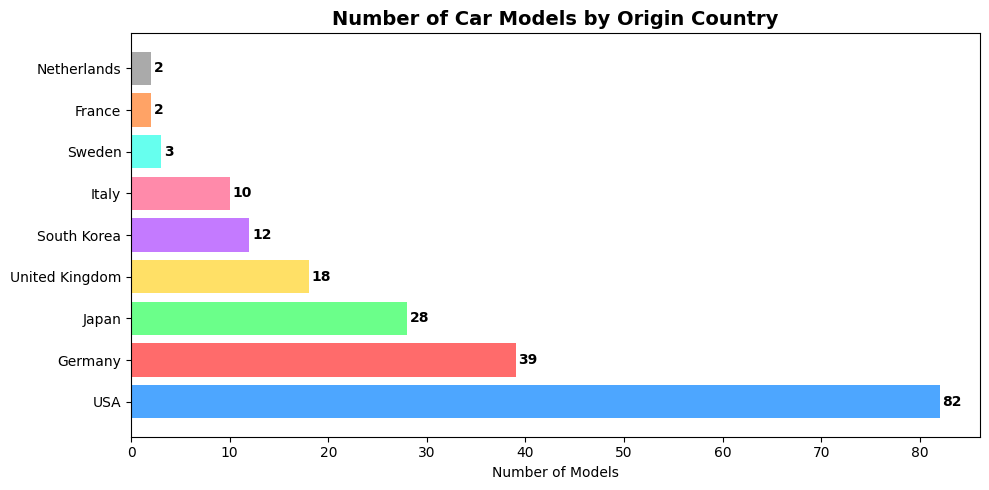

origin_country
USA               82
Germany           39
Japan             28
United Kingdom    18
South Korea       12
Italy             10
Sweden             3
France             2
Netherlands        2


In [7]:
plt.figure(figsize=(10, 5))
origin_counts = df['origin_country'].value_counts()

colors = ['#4da6ff','#ff6b6b','#6bff8a','#ffe066','#c47aff','#ff8aaa','#66ffee','#ffa366','#aaaaaa']
bars = plt.barh(origin_counts.index, origin_counts.values, color=colors[:len(origin_counts)])

plt.title('Number of Car Models by Origin Country', fontsize=14, fontweight='bold')
plt.xlabel('Number of Models')

for bar, val in zip(bars, origin_counts.values):
    plt.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             str(val), va='center', fontweight='bold')

plt.tight_layout()
plt.show()
print(origin_counts.to_string())

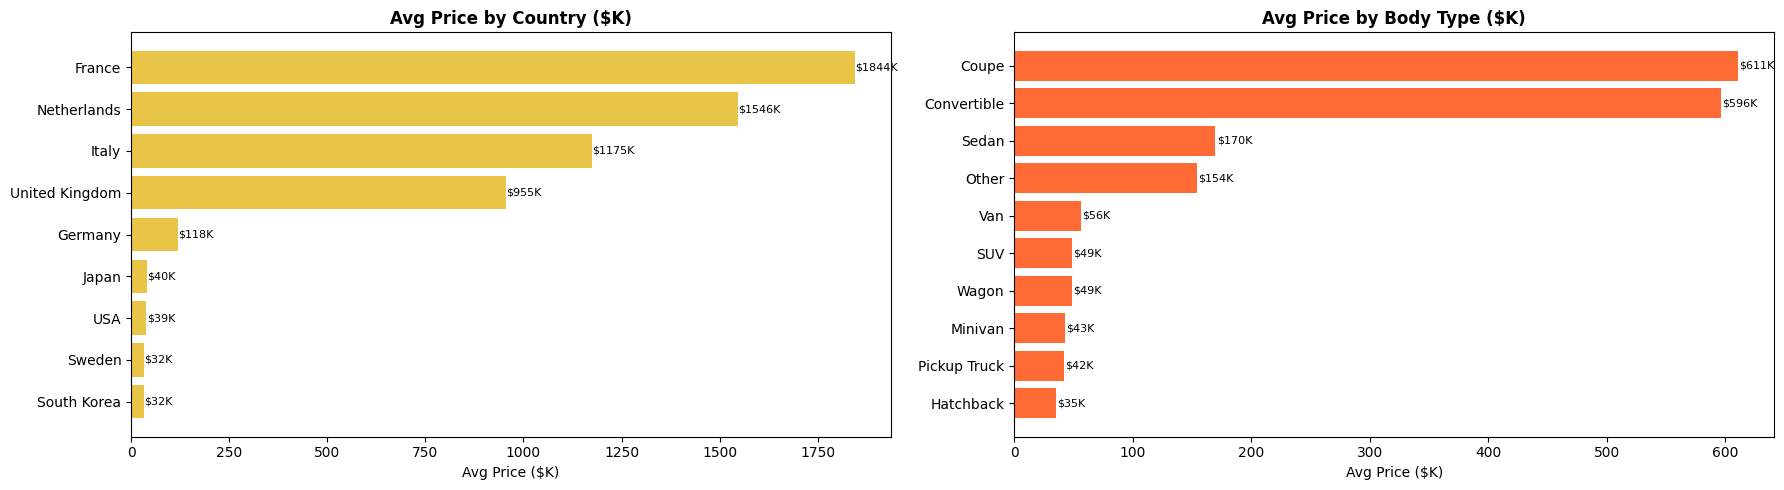

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Avg price by origin
price_origin = df.groupby('origin_country')['avg_price_usd'].mean().sort_values(ascending=True)
axes[0].barh(price_origin.index, price_origin.values / 1000, color='#e8c547')
axes[0].set_title('Avg Price by Country ($K)', fontweight='bold')
axes[0].set_xlabel('Avg Price ($K)')
for i, v in enumerate(price_origin.values):
    axes[0].text(v/1000 + 1, i, f'${v/1000:.0f}K', va='center', fontsize=8)

# Avg price by body type
price_body = df.groupby('body_type')['avg_price_usd'].mean().sort_values(ascending=True)
axes[1].barh(price_body.index, price_body.values / 1000, color='#ff6b35')
axes[1].set_title('Avg Price by Body Type ($K)', fontweight='bold')
axes[1].set_xlabel('Avg Price ($K)')
for i, v in enumerate(price_body.values):
    axes[1].text(v/1000 + 1, i, f'${v/1000:.0f}K', va='center', fontsize=8)



plt.tight_layout()
plt.show()

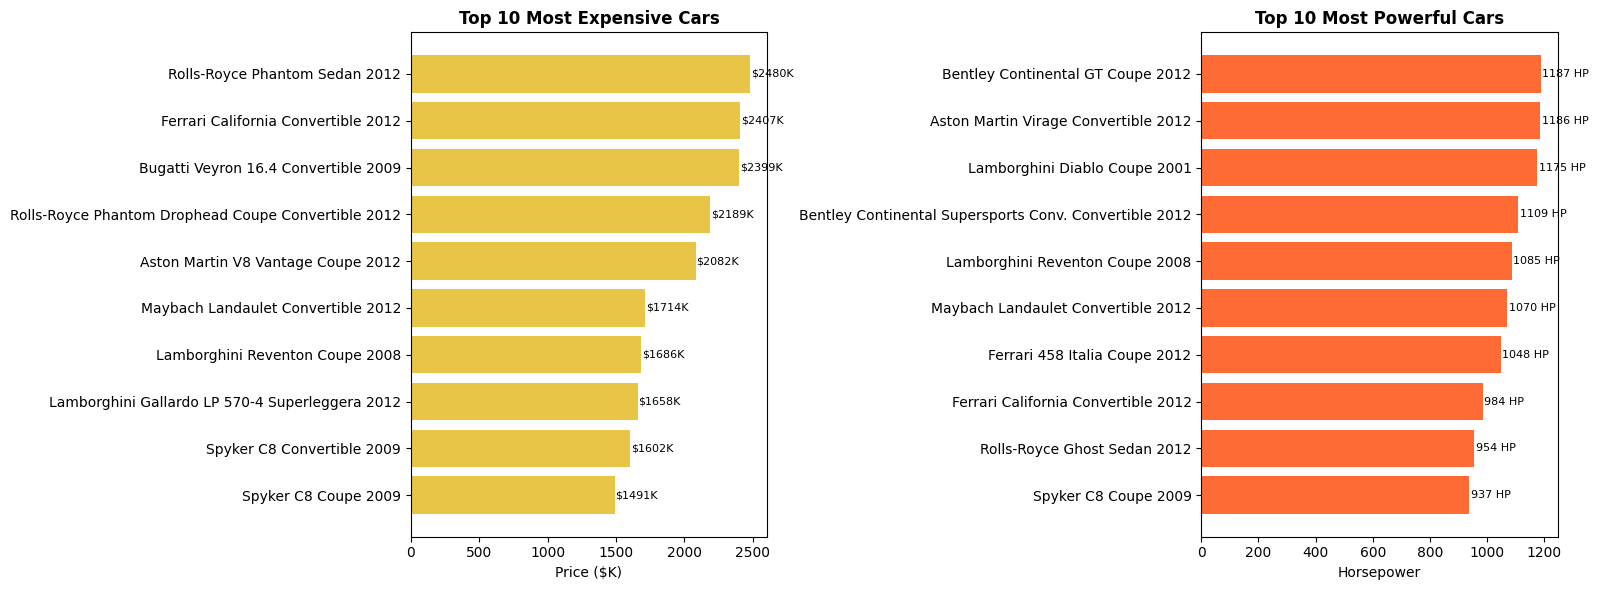

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Top 10 most expensive
top_price = df.nlargest(10, 'avg_price_usd')[['class_name','avg_price_usd']].sort_values('avg_price_usd')
ax1.barh(top_price['class_name'], top_price['avg_price_usd'] / 1000, color='#e8c547')
ax1.set_title('Top 10 Most Expensive Cars', fontweight='bold')
ax1.set_xlabel('Price ($K)')
for i, v in enumerate(top_price['avg_price_usd'].values):
    ax1.text(v/1000 + 5, i, f'${v/1000:.0f}K', va='center', fontsize=8)

# Top 10 most powerful
top_hp = df.nlargest(10, 'horsepower')[['class_name','horsepower']].sort_values('horsepower')
ax2.barh(top_hp['class_name'], top_hp['horsepower'], color='#ff6b35')
ax2.set_title('Top 10 Most Powerful Cars', fontweight='bold')
ax2.set_xlabel('Horsepower')
for i, v in enumerate(top_hp['horsepower'].values):
    ax2.text(v + 5, i, f'{v} HP', va='center', fontsize=8)

plt.tight_layout()
plt.show()

In [15]:
car_database = {}
for _, row in df.iterrows():
    car_database[int(row["class_id"])] = {
        "class_name":     row["class_name"],
        "manufacturer":   row["manufacturer"],
        "model":          row["model"],
        "year":           row["year"],
        "origin_country": row["origin_country"],
        "body_type":      row["body_type"],
        "horsepower":     row["horsepower"],
        "engine":         row["engine"],
        "0_to_60":        row["0_to_60_mph_sec"],
        "top_speed":      row["top_speed_mph"],
        "transmission":   row["transmission"],
        "avg_price":      row["avg_price_usd"],
    }

num_classes  = len(df)
idx_to_class = dict(zip(df["class_id"], df["class_name"]))
print(f"Cars in database : {num_classes}")
print(f"Example: ID 10 → {idx_to_class[10]}")

Cars in database : 196
Example: ID 10 → Aston Martin Virage Convertible 2012


In [17]:
import scipy.io as sio
import pandas as pd
import os
import glob

# --- Auto-locate the devkit folder, in case Kaggle nests an extra directory level ---
candidates = glob.glob("extra_data/**/devkit", recursive=True)
if not candidates:
    raise FileNotFoundError(
        "Couldn't find a 'devkit' folder under extra_data/. "
        "Run: !find extra_data -maxdepth 5 -type d   to see the actual structure, "
        "then set devkit_dir manually."
    )
devkit_dir = candidates[0]
print(f"Using devkit dir: {devkit_dir}")

def mat_to_df(mat_path):
    mat = sio.loadmat(mat_path)
    annos = mat["annotations"][0]
    rows = []
    for a in annos:
        rows.append({
            "filename": a["fname"][0],
            "x1": int(a["bbox_x1"][0][0]),
            "y1": int(a["bbox_y1"][0][0]),
            "x2": int(a["bbox_x2"][0][0]),
            "y2": int(a["bbox_y2"][0][0]),
            "class_id": int(a["class"][0][0]),
        })
    return pd.DataFrame(rows)

# --- Train annotations ---
train_mat_path = os.path.join(devkit_dir, "cars_train_annos.mat")
anno_train = mat_to_df(train_mat_path)

# --- Test annotations: prefer the version WITH labels; fall back if only unlabeled exists ---
test_mat_name = "cars_test_annos_withlabels.mat"
if not os.path.exists(os.path.join(devkit_dir, test_mat_name)):
    # some uploads put the labeled version one level up, next to devkit
    parent = os.path.dirname(devkit_dir)
    alt_path = os.path.join(parent, test_mat_name)
    if os.path.exists(alt_path):
        test_mat_path = alt_path
    else:
        test_mat_name = "cars_test_annos.mat"  # WARNING: this one has NO class_id (real test set)
        test_mat_path = os.path.join(devkit_dir, test_mat_name)
        print("⚠️ Only found cars_test_annos.mat (no labels) — class_id for test set will be missing/invalid.")
else:
    test_mat_path = os.path.join(devkit_dir, test_mat_name)

anno_test = mat_to_df(test_mat_path)

# --- Write out exactly the files your notebook expects, in the working directory ---
anno_train.to_csv("anno_train.csv", header=False, index=False)
anno_test.to_csv("anno_test.csv", header=False, index=False)

print(f"anno_train.csv: {len(anno_train)} rows")
print(f"anno_test.csv : {len(anno_test)} rows")
print(anno_train.head())

Using devkit dir: extra_data/car_data/stanford_cars/devkit
anno_train.csv: 8144 rows
anno_test.csv : 8041 rows
    filename   x1   y1    x2    y2  class_id
0  00001.jpg   39  116   569   375        14
1  00002.jpg   36  116   868   587         3
2  00003.jpg   85  109   601   381        91
3  00004.jpg  621  393  1484  1096       134
4  00005.jpg   14   36   133    99       106


In [18]:
anno_train = pd.read_csv("anno_train.csv", header=None,
                          names=["filename","x1","y1","x2","y2","class_id"])
anno_test  = pd.read_csv("anno_test.csv",  header=None,
                          names=["filename","x1","y1","x2","y2","class_id"])

anno_train["label"] = anno_train["class_id"] - 1
anno_test["label"]  = anno_test["class_id"]  - 1

train_dir = "extra_data/car_data/stanford_cars/cars_train"
test_dir  = "extra_data/car_data/stanford_cars/cars_test"

train_paths  = [os.path.join(train_dir, f) for f in anno_train["filename"]]
train_labels = anno_train["label"].tolist()
test_paths   = [os.path.join(test_dir,  f) for f in anno_test["filename"]]
test_labels  = anno_test["label"].tolist()

train_paths, val_paths, train_labels, val_labels = train_test_split(
    train_paths, train_labels,
    test_size=0.15, random_state=42, stratify=train_labels
)

print(f"Train : {len(train_paths)}")
print(f"Val   : {len(val_paths)}")
print(f"Test  : {len(test_paths)}")

Train : 6922
Val   : 1222
Test  : 8041


In [19]:
from sklearn.model_selection import train_test_split
import pandas as pd
import os

train_dir = "extra_data/car_data/stanford_cars/cars_train"
test_dir  = "extra_data/car_data/stanford_cars/cars_test"

# Load annotation files to correctly get filenames and labels
anno_train = pd.read_csv("anno_train.csv", header=None,
                          names=["filename","x1","y1","x2","y2","class_id"])
anno_test  = pd.read_csv("anno_test.csv",  header=None,
                          names=["filename","x1","y1","x2","y2","class_id"])

# Adjust class_id to be 0-indexed labels
# The 'class_id' in these anno files range from 1 to 196. So labels will be 0 to 195.
anno_train["label"] = anno_train["class_id"] - 1
anno_test["label"]  = anno_test["class_id"]  - 1

# Get the correct number of classes and class mappings
df_car_data = pd.read_csv("stanford_cars_full_dataset.csv")

# Filter `df_car_data` for the class_ids (1-196) present in anno_train/test
# And add a 0-indexed label column for mapping
relevant_df_car_data = df_car_data[df_car_data["class_id"].between(1, 196)].copy()
relevant_df_car_data["0_indexed_label"] = relevant_df_car_data["class_id"] - 1

idx_to_class = dict(zip(relevant_df_car_data["0_indexed_label"], relevant_df_car_data["class_name"]))
num_classes = len(idx_to_class) # This should be 196

print(f"Classes found: {num_classes}")

# Build train paths & labels using the annotation dataframe
train_paths  = [os.path.join(train_dir, fname) for fname in anno_train["filename"]]
train_labels = anno_train["label"].tolist()

# Build test paths & labels using the annotation dataframe
test_paths   = [os.path.join(test_dir,  fname) for fname in anno_test["filename"]]
test_labels  = anno_test["label"].tolist()

# Train/Val split
train_paths, val_paths, train_labels, val_labels = train_test_split(
    train_paths, train_labels,
    test_size=0.15, random_state=42, stratify=train_labels
)

print(f"Train : {len(train_paths)}")
print(f"Val   : {len(val_paths)}")
print(f"Test  : {len(test_paths)}")

Classes found: 196
Train : 6922
Val   : 1222
Test  : 8041


In [20]:
# Rebuild car_database to be 0-indexed (0-195) and contain all details
car_database = {}
for _, row in relevant_df_car_data.iterrows(): # Use the filtered and prepared df from 3orI2Swwxi3T
    zero_indexed_label = row["0_indexed_label"] # This will be 0-195
    car_database[zero_indexed_label] = {
        "class_name":     row["class_name"],
        "manufacturer":   row["manufacturer"],
        "model":          row["model"],
        "year":           row["year"],
        "origin_country": row["origin_country"],
        "body_type":      row["body_type"],
        "horsepower":     row["horsepower"],
        "engine":         row["engine"],
        "0_to_60":        row["0_to_60_mph_sec"],
        "top_speed":      row["top_speed_mph"],
        "transmission":   row["transmission"],
        "avg_price":      row["avg_price_usd"],
    }

print(f"Cars in database: {num_classes}") # num_classes is 196
print(f"Example: {car_database[0]}")

Cars in database: 196
Example: {'class_name': 'AM General Hummer SUV 2000', 'manufacturer': 'AM General', 'model': 'Hummer', 'year': 2000, 'origin_country': 'USA', 'body_type': 'SUV', 'horsepower': 323, 'engine': '2.5L 4-Cylinder', '0_to_60': 6.1, 'top_speed': 132, 'transmission': 'Automatic', 'avg_price': 26296}


In [21]:
transforms.RandomHorizontalFlip(),
transforms.RandomRotation(15),
transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
transforms.RandomPerspective(distortion_scale=0.2),  # add this
transforms.RandomErasing(p=0.1),

(RandomErasing(p=0.1, scale=(0.02, 0.33), ratio=(0.3, 3.3), value=0, inplace=False),)

In [22]:
IMG_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.RandomGrayscale(p=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

class CarDataset(Dataset):
    def __init__(self, paths, labels, transform):
        self.paths     = paths
        self.labels    = labels
        self.transform = transform
    def __len__(self):
        return len(self.paths)
    def __getitem__(self, i):
        img = Image.open(self.paths[i]).convert("RGB")
        return self.transform(img), self.labels[i]

BATCH_SIZE = 32

train_loader = DataLoader(CarDataset(train_paths, train_labels, train_transform),
                          batch_size=BATCH_SIZE, shuffle=True,  num_workers=0) # Changed num_workers to 0
val_loader   = DataLoader(CarDataset(val_paths,   val_labels,   val_transform),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=0) # Changed num_workers to 0
test_loader  = DataLoader(CarDataset(test_paths,  test_labels,  val_transform),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=0) # Changed num_workers to 0

imgs, lbls = next(iter(train_loader))
print(f"Batch shape : {imgs.shape}")
print("DataLoaders ready ✅")

Batch shape : torch.Size([32, 3, 224, 224])
DataLoaders ready ✅


In [23]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for images, labels in tqdm(loader, desc="  Train", leave=False):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss    = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += labels.size(0)
    return total_loss / total, 100 * correct / total

def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="  Eval", leave=False):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss    = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            correct    += (outputs.argmax(1) == labels).sum().item()
            total      += labels.size(0)
    return total_loss / total, 100 * correct / total

print("Training functions ready ")

Training functions ready 


In [24]:
# ── Build ResNet-50 ──
backbone = models.resnet50(pretrained=True)
backbone.fc = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(backbone.fc.in_features, num_classes)
)
model = backbone.to(device)
print(f"ResNet-50 ready  Params: {sum(p.numel() for p in model.parameters()):,}")

criterion    = nn.CrossEntropyLoss(label_smoothing=0.1)
history      = {"train_loss":[], "train_acc":[], "val_loss":[], "val_acc":[]}
best_val_acc = 0

# ── PHASE 1: Freeze all except final layer (5 epochs) ──
print("\nPHASE 1: Head only (5 epochs)")
print("=" * 50)

for name, param in model.named_parameters():
    param.requires_grad = "fc" in name

optimizer = torch.optim.Adam(model.fc.parameters(), lr=0.001)

for epoch in range(5):
    tl, ta = train_one_epoch(model, train_loader, criterion, optimizer)
    vl, va = evaluate(model, val_loader, criterion)
    history["train_loss"].append(tl); history["train_acc"].append(ta)
    history["val_loss"].append(vl);   history["val_acc"].append(va)
    print(f"  Epoch {epoch+1}/5 | Train: {ta:.1f}% | Val: {va:.1f}%")

# ── PHASE 2: Fine-tune all (25 epochs) ──
print("\nPHASE 2: Fine-tune all (25 epochs)")
print("=" * 50)

for param in model.parameters():
    param.requires_grad = True

optimizer = torch.optim.Adam([
    {"params": [p for n,p in model.named_parameters() if "fc" not in n], "lr": 0.00001},
    {"params": model.fc.parameters(), "lr": 0.0001},
])
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=25)

for epoch in range(25):
    tl, ta = train_one_epoch(model, train_loader, criterion, optimizer)
    vl, va = evaluate(model, val_loader, criterion)
    scheduler.step()
    history["train_loss"].append(tl); history["train_acc"].append(ta)
    history["val_loss"].append(vl);   history["val_acc"].append(va)
    saved = ""
    if va > best_val_acc:
        best_val_acc = va
        torch.save(model.state_dict(), "best_model.pth")
        saved = " ← saved!"
    print(f"  Epoch {epoch+6}/30 | Train: {ta:.1f}% | Val: {va:.1f}%{saved}")

# ── PHASE 3: Low LR squeeze (10 epochs) ──
print("\nPHASE 3: Low LR squeeze (10 epochs)")
print("=" * 50)

optimizer = torch.optim.Adam([
    {"params": [p for n,p in model.named_parameters() if "fc" not in n], "lr": 0.000003},
    {"params": model.fc.parameters(), "lr": 0.00003},
])
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

for epoch in range(10):
    tl, ta = train_one_epoch(model, train_loader, criterion, optimizer)
    vl, va = evaluate(model, val_loader, criterion)
    scheduler.step()
    history["train_loss"].append(tl); history["train_acc"].append(ta)
    history["val_loss"].append(vl);   history["val_acc"].append(va)
    saved = ""
    if va > best_val_acc:
        best_val_acc = va
        torch.save(model.state_dict(), "best_model.pth")
        saved = " ← saved!"
    print(f"  Epoch {epoch+31}/40 | Train: {ta:.1f}% | Val: {va:.1f}%{saved}")

# ── Final Test ──
model.load_state_dict(torch.load("best_model.pth"))
test_loss, test_acc = evaluate(model, test_loader, criterion)
print(f"\n{'='*50}")
print(f"  Best Val Accuracy  : {best_val_acc:.1f}%")
print(f"  Final Test Accuracy: {test_acc:.1f}%")
print(f"{'='*50}")

/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 166MB/s]


ResNet-50 ready  Params: 23,909,636

PHASE 1: Head only (5 epochs)


  Epoch 1/5 | Train: 3.2% | Val: 9.2%


...

  Epoch 37/40 | Train: 94.5% | Val: 78.2%


  Epoch 38/40 | Train: 95.2% | Val: 78.5% ← saved!


  Epoch 39/40 | Train: 95.0% | Val: 78.2%


  Epoch 40/40 | Train: 95.0% | Val: 78.6% ← saved!



  Best Val Accuracy  : 78.6%
  Final Test Accuracy: 77.8%


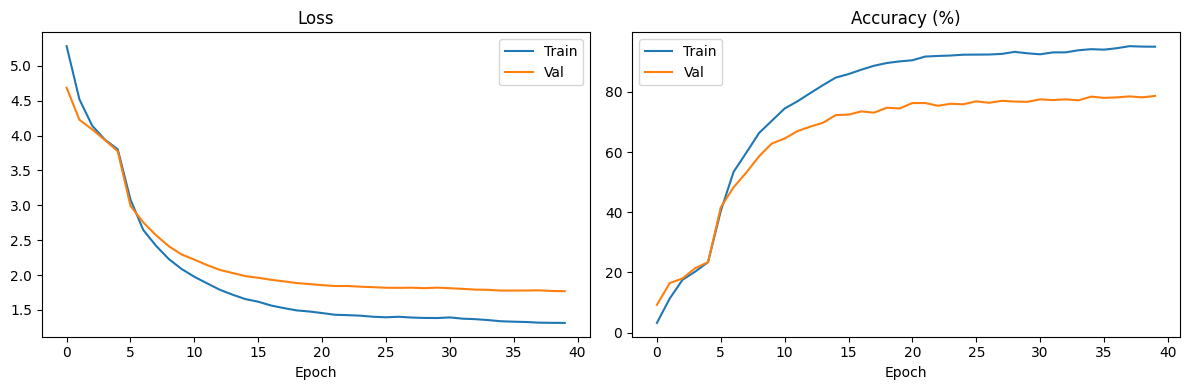

In [25]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history["train_loss"], label="Train")
ax1.plot(history["val_loss"],   label="Val")
ax1.set_title("Loss"); ax1.set_xlabel("Epoch"); ax1.legend()

ax2.plot(history["train_acc"], label="Train")
ax2.plot(history["val_acc"],   label="Val")
ax2.set_title("Accuracy (%)"); ax2.set_xlabel("Epoch"); ax2.legend()

plt.tight_layout()
plt.show()

In [26]:
def predict(image_path):
    img = Image.open(image_path).convert('RGB')
    # Apply the same transformation used for validation
    transformed_img = val_transform(img).unsqueeze(0).to(device) # Add batch dimension and move to device

    model.eval() # Set model to evaluation mode
    with torch.no_grad():
        outputs = model(transformed_img)
        probabilities = torch.nn.functional.softmax(outputs, dim=1)

        # Get predicted class and confidence
        confidence, predicted = torch.max(probabilities.data, 1)
        confidence = confidence.item() * 100 # Convert to percentage

        # Get top 5 predictions
        top5_probs, top5_idx = torch.topk(probabilities, 5)

    predicted_class_id = predicted.item()
    predicted_class_name = idx_to_class[predicted_class_id]

    # Retrieve car information from the database
    # car_database is now 0-indexed (0-195)
    info = car_database.get(predicted_class_id, {}) # Use predicted_class_id directly as key

    print(f"Predicted label: {predicted_class_name}")
    print("=" * 50)
    print("        🚗  CAR REPORT")
    print("=" * 50)
    print(f"  Car          : {info.get('class_name',     '?')}")
    print(f"  Confidence   : {confidence:.1f}%")
    print(f"  Manufacturer : {info.get('manufacturer',   '?')}")
    print(f"  Origin       : {info.get('origin_country', '?')}")
    print(f"  Year         : {info.get('year',           '?')}")
    print(f"  Body Type    : {info.get('body_type',      '?')}")
    print(f"  Horsepower   : {info.get('horsepower',     '?')} HP")
    print(f"  Engine       : {info.get('engine',         '?')}")
    print(f"  0-60 mph     : {info.get('0_to_60',        '?')} sec")
    print(f"  Top Speed    : {info.get('top_speed',      '?')} mph")
    print(f"  Transmission : {info.get('transmission',   '?')}")

    # Handle formatting of Avg Price to avoid ValueError if it's '?'
    avg_price_val = info.get('avg_price', '?')
    if avg_price_val == '?':
        formatted_avg_price = '?'
    else:
        # Assuming avg_price_usd is numeric (int or float)
        formatted_avg_price = f"{avg_price_val:,.0f}"
    print(f"  Avg Price    : ${formatted_avg_price}")

    print("=" * 50)

    print("\n  Top 5 Predictions:")
    print("  " + "-" * 35)
    for i in range(5):
        name = idx_to_class[top5_idx[0][i].item()] # top5_idx is a 2D tensor, access with [0][i]
        prob = top5_probs[0][i].item() * 100        # top5_probs is a 2D tensor, access with [0][i]
        print(f"  {i+1}. {name:<30} {prob:.1f}%")


import random
random_idx = random.randint(0, len(test_paths) - 1)
print(f"True label: {idx_to_class[test_labels[random_idx]]}\n")
predict(test_paths[random_idx])

True label: AM General Hummer SUV 2000

Predicted label: AM General Hummer SUV 2000
        🚗  CAR REPORT
  Car          : AM General Hummer SUV 2000
  Confidence   : 87.3%
  Manufacturer : AM General
  Origin       : USA
  Year         : 2000
  Body Type    : SUV
  Horsepower   : 323 HP
  Engine       : 2.5L 4-Cylinder
  0-60 mph     : 6.1 sec
  Top Speed    : 132 mph
  Transmission : Automatic
  Avg Price    : $26,296

  Top 5 Predictions:
  -----------------------------------
  1. AM General Hummer SUV 2000     87.3%
  2. HUMMER H2 SUT Crew Cab 2009    5.0%
  3. Ford F-450 Super Duty Crew Cab 2012 2.2%
  4. Jeep Wrangler SUV 2012         0.6%
  5. HUMMER H3T Crew Cab 2010       0.5%


Upload a car image...


Saving 2549-0-medium.jpg to 2549-0-medium.jpg

Analyzing: 2549-0-medium.jpg
Predicted label: Rolls-Royce Phantom Sedan 2012
        🚗  CAR REPORT
  Car          : Rolls-Royce Phantom Sedan 2012
  Confidence   : 74.0%
  Manufacturer : Rolls-Royce
  Origin       : United Kingdom
  Year         : 2012
  Body Type    : Sedan
  Horsepower   : 781 HP
  Engine       : 3.9L 10-Cylinder
  0-60 mph     : 3.6 sec
  Top Speed    : 238 mph
  Transmission : Dual-Clutch
  Avg Price    : $2,479,973

  Top 5 Predictions:
  -----------------------------------
  1. Rolls-Royce Phantom Sedan 2012 74.0%
  2. Rolls-Royce Ghost Sedan 2012   22.4%
  3. Chrysler 300 SRT-8 2010        0.7%
  4. Rolls-Royce Phantom Drophead Coupe Convertible 2012 0.4%
  5. Bentley Mulsanne Sedan 2011    0.4%


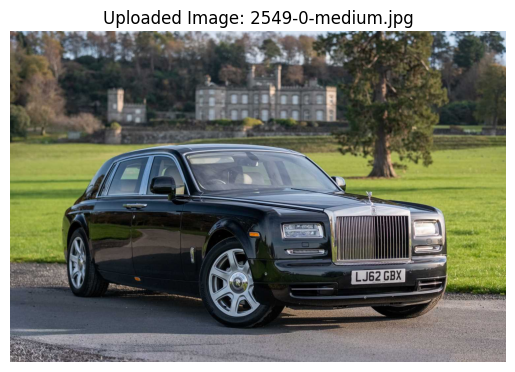

In [30]:
from google.colab import files
import matplotlib.pyplot as plt
from PIL import Image

print("Upload a car image...")
uploaded = files.upload()

for filename in uploaded:
    print(f"\nAnalyzing: {filename}")
    predict(filename)

    # Display the uploaded image
    img = Image.open(filename)
    plt.imshow(img)
    plt.title(f"Uploaded Image: {filename}")
    plt.axis('off')
    plt.show()